**Author**: Adrian Vanyi

# Factors Model

This notebook fits the cross-sectional linear factors model of §8 of the documentation. At each rebalance date $t_k$, the model pools the preceding $W_{\text{factor}}$ rebalance dates (e.g. $W_{\text{factor}} = 6$). The realised returns over the upcoming period of every pooled date (ending at the next rebalance date) for every ticker in the investable universe on that date, are stacked together in a vector, and we regress it against the corresponding stacked factors momentum and volatility (cross-sectionally winsorised and z-scored) (see §8.6 of the docuemntation). The fitted coefficients are then applied at $t_k$ to produce an out-of-sample forward-return prediction, which serves as the ranking signal for the long-top-$k$ / short-bottom-$k$ selection rule.

The notebook does three things:

1. Fit and predict at a single rebalance date, inspecting the fitted coefficients, in-sample metrics, out-of-sample metrics, and condition number of the design matrix (see §8.10 of the doc.).
2. Run the fit-and-predict across all rebalance dates of the backtest calendar and aggregate the diagnostics.
3. Sweep the rolling-window length $W_{\text{factor}}$ and report the average out-of-sample overall sign hit rate across rebalance dates for each candidate (see §8.11 of the doc).

**Prerequisite:** The relevant data files (S&P 500 historical members and price data) must already be present in `../data/`. If they are not, run `python download_data.py` from the project root first.

### Contents
0. Setup
1. Load pre-downloaded data (and filter out bad tickers)
2. Configure the backtest calendar
3. Build per-rebalance-date universes
4. Fit (and predict with) the factors model at one selected rebalance date
5. In-sample and out-of-sample metrics across all rebalance dates
6. Sweep the rolling-window length $W_{\text{factor}}$

## 0. Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
    
from modules import logging_setup
from  modules import backtest_calendar as bcal
from  modules import universe_construction as uc
from  modules import factors_engineering as fe
from modules import returns_prediction_model as rpm
from modules import market_data as md


logging_setup.configure(level="INFO", stream = sys.stdout)

DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
OUTPUTS_DIR.mkdir(exist_ok=True)

## 1. Load pre-downloaded data (and filter out bad tickers)
*(The filtering out of bad tickers is explained in §6.5 and in the Appendix of the documentation*.)

In [3]:
expected_files = [
    "sp500_members_at_start_of_months.parquet",
    "prices_sp500_members.parquet",
]
missing = [f for f in expected_files if not (DATA_DIR / f).exists()]
if missing:
    raise FileNotFoundError(
        f"data files missing in {DATA_DIR}: {missing}. "
        f"Run `python download_data.py` from the project root first."
    )

# S&P 500 monthly historical members (DataFrame: index=first trading day of
# month, columns are member tickers, eventually extended with NaN to form a uniform width).
sp500_members_at_first_trading_day_of_every_month = pd.read_parquet(
    DATA_DIR / "sp500_members_at_start_of_months.parquet"
)
first_trading_day_of_month_to_sp500_members_dict = {
    idx: row.dropna().tolist()
    for idx, row in sp500_members_at_first_trading_day_of_every_month.iterrows()
}

# Daily price panel for all S&P 500 members during the data window
price_data = pd.read_parquet(DATA_DIR / "prices_sp500_members.parquet")


print(f"price data: {len(price_data):,} (date, ticker) rows")

# --- filter out bad tickers
price_data, bad_tickers = uc.remove_bad_tickers(price_data)

close_prices = price_data["close"]

all_tickers_during_backtest = (
    price_data.index.get_level_values("ticker").unique().to_list()
)

print(f"dropped {len(bad_tickers)} bad ticker(s)")

if not bad_tickers.empty:
    print(bad_tickers.head(10))
    
print(f"clean universe: {len(all_tickers_during_backtest)} tickers")

price data: 4,362,440 (date, ticker) rows
[INFO modules.universe_construction, remove_bad_tickers:287]  removing 84 ticker(s) with bad data (zero_volume=82, extreme_return=16)
dropped 84 bad ticker(s)
        zero_volume  extreme_return
ticker                             
ABI            True           False
AET            True           False
AMCR           True           False
AMD            True           False
ANDV           True           False
BHF            True           False
BKR            True           False
BMC            True            True
BOL            True            True
CA             True           False
clean universe: 871 tickers


## 2. Configure the backtest calendar

In [ ]:
# ---- Rebalance frequency and number of periods ----
start = pd.Timestamp("2023-01-05")  # automatically snapped backward to closest trading day, if needed
rebalance_freq_type = "ndays"     # "ndays" or "monthly"
rebalance_frequency_trading_days = 21
number_of_inter_rebalance_periods = 12  # covering ~1 calendar year (given the rebalance frequency of 21 trading days)

# ---- Estimation windows for portfolio-construction inputs  ----
rolling_periods_for_cov_matrix_estimation = 18
rolling_periods_for_beta_regression = 12
rolling_periods_for_avg_return_computation = 12
rolling_periods_for_factors_model_regression = 6

number_of_training_inter_rebalance_periods = max(
    rolling_periods_for_factors_model_regression,
    rolling_periods_for_cov_matrix_estimation,
    rolling_periods_for_beta_regression,
    rolling_periods_for_avg_return_computation
)

# ---- Trading-day rolling windows for daily features  ----
rolling_window_trading_days_for_volatility = 60
rolling_window_trading_days_for_momentum = 4 * 23   # ~4 trading months
buffer_trading_days_for_momentum = 23                # ~1 trading month skip
rolling_window_trading_days_for_adv = 60             # used only when capping universes


# ---- Build the calendar  ----
backtest_calendar = bcal.build_calendar(
                            start = start,
                            freq_type = rebalance_freq_type,
                            P = number_of_inter_rebalance_periods,
                            P_train = number_of_training_inter_rebalance_periods,
                            freq = rebalance_frequency_trading_days
                        )

scheduled_rebalance_dates = backtest_calendar.rebalance_dates
scheduled_training_rebalance_dates = backtest_calendar.training_rebalance_dates
backtest_dates = backtest_calendar.backtest_dates

print(
    f"backtest period: {backtest_dates[0]:%Y-%m-%d} to "
    f"{backtest_dates[-1]:%Y-%m-%d} ({len(backtest_dates)} trading days)"
)
print(
    f"rebalance dates: {len(scheduled_rebalance_dates)} "
    f"(training rebalance dates prepended: {len(scheduled_training_rebalance_dates) - len(scheduled_rebalance_dates)})"
)

# ---- Validate that we have enough data history ----
fetch_start, fetch_end = md.compute_price_data_window(
                                backtest_dates,
                                scheduled_training_rebalance_dates,
                                rolling_window_trading_days_for_momentum,
                                buffer_trading_days_for_momentum,
                                rolling_window_trading_days_for_volatility,
                                rolling_window_trading_days_for_adv
                            )

earliest_supported_date = pd.Timestamp("2008-01-01") # (see documentation, §6.2)
latest_supported_date = pd.Timestamp("2026-02-27")   # choose, at the latest, the last fetch date for price_data

if fetch_start < earliest_supported_date:
    raise ValueError(
        f"backtest needs data back to {fetch_start:%Y-%m-%d}, but earliest "
        f"supported date is {earliest_supported_date:%Y-%m-%d}. Choose a later start."
    )
if fetch_end > latest_supported_date:
    raise ValueError(
        f"backtest extends to {fetch_end:%Y-%m-%d}, but latest supported "
        f"date is {latest_supported_date:%Y-%m-%d}. Reduce P or pick an earlier start."
    )
print(f"data window required: {fetch_start:%Y-%m-%d} to {fetch_end:%Y-%m-%d}")

backtest period: 2023-01-05 to 2024-02-07 (274 trading days)
rebalance dates: 13 (training rebalance dates prepended: 18)
data window required: 2021-01-21 to 2024-02-08


## 3. Build per-rebalance-date universes

*(see documentation, §6)*

In [5]:
capping_num_tickers_per_universe = None  # set to None or to an integer (e.g. 200 to cap at top-200 by ADV)
if capping_num_tickers_per_universe is not None:
    price_data = uc.compute_adv(price_data, adv_window=rolling_window_trading_days_for_adv)


scheduled_reb_date_to_tickers_universe_dict, eligibility_criteria = (
                        uc.build_pit_universes(
                            scheduled_training_rebalance_dates,
                            final_period_end_date = backtest_dates[-1],
                            first_trading_day_of_month_to_sp500_members_dict =(
                                first_trading_day_of_month_to_sp500_members_dict
                            ),
                        price_data = price_data,
                        require_prices_for_next_period = True,
                        capping_num_tickers_per_universe = capping_num_tickers_per_universe,
                        )
)   


first_reb = scheduled_rebalance_dates[0]
last_reb = scheduled_rebalance_dates[-1]
print(
    f"universe size at first rebalance ({first_reb:%Y-%m-%d}): "
    f"{len(scheduled_reb_date_to_tickers_universe_dict[first_reb])}"
)
print(
    f"universe size at last rebalance ({last_reb:%Y-%m-%d}): "
    f"{len(scheduled_reb_date_to_tickers_universe_dict[last_reb])}"
)

print("\n head of dataframe of eligibility criteria: \n")

eligibility_criteria.head()

universe size at first rebalance (2023-01-05): 460
universe size at last rebalance (2024-01-08): 466

 head of dataframe of eligibility criteria: 



forward_close_prices_available  \
training_rebalance_date ticker                                   
2021-07-07              A                                 True   
                        AAL                               True   
                        AAP                               True   
                        AAPL                              True   
                        ABBV                              True   

                                forward_open_prices_available  
training_rebalance_date ticker                                 
2021-07-07              A                                True  
                        AAL                              True  
                        AAP                              True  
                        AAPL                             True  
                        ABBV                             True

## 4. Fit (and predict with) the factors model at one selected rebalance date

**Configuration:**

In [ ]:
date = scheduled_rebalance_dates[0] # select any date in `scheduled_rebalance_dates`

use_ridge = False 
ridge_penalty = 0.01

winsorize_factors_per_date = True 
z_score_factors_per_date = True

selection_k = 10 # For the sign-hit rates computation (see §8.11), in the context of the top-k/bottom-k tickers selected for trading by the strategy

**Fit the model and then use it for the predictions:**

In [7]:
# build training dates to fit the model
local_training_dates =  (bcal.build_calendar(date,
                                                rebalance_freq_type,
                                                P = 0,
                                                P_train = rolling_periods_for_factors_model_regression,
                                                freq = rebalance_frequency_trading_days,
                                                )
                                    .training_rebalance_dates
                            )

# --- computation of the factors:
factors = fe.compute_factors_at_training_rebalance_dates(
    prices = close_prices,
    training_rebalance_dates = local_training_dates,
    rolling_window_trading_days_for_momentum = rolling_window_trading_days_for_momentum,
    buffer_trading_days_for_momentum = buffer_trading_days_for_momentum,
    rolling_window_trading_days_for_volatility = rolling_window_trading_days_for_volatility,
    reb_date_to_tickers_universe_dict = None, # no mapping of reb_date -> tickers provided. Therefore, function takes all tickers available in `close_prices` for each each reb. date 
    winsorize_factors_per_date = winsorize_factors_per_date,
    z_score_factors_per_date = z_score_factors_per_date
)

# --- computation of realized forward returns:
if date == scheduled_rebalance_dates[-1]:
    next_end = self.last_backtest_date
else:
    idx = scheduled_rebalance_dates.get_loc(date)
    next_end = scheduled_rebalance_dates[idx + 1]

fwd_returns = rpm.compute_realized_period_returns(
    close_prices, local_training_dates, next_end, None
)

model_input = pd.concat([factors, fwd_returns], axis=1, join="inner")

factors_model_result = rpm.fit_predict_factors_model_at_date(
    date,
    local_training_dates,
    model_input,
    rolling_periods=rolling_periods_for_factors_model_regression,
    use_ridge = use_ridge,
    ridge_penalty = ridge_penalty,
    selection_k = selection_k
)

#### Predictions

In [8]:
factors_model_result.predictions

ticker
A       0.013689
AA      0.016869
AAL     0.011098
AAP     0.005667
AAPL    0.009359
          ...   
YUM     0.007992
ZBH     0.010688
ZBRA    0.009211
ZION    0.010096
ZTS     0.007302
Name: prediction, Length: 591, dtype: float64

#### Model fit metrics

We fit on the date previous to the date chosen (using the realized return of that inter-rebalance dates period), and use the fitted model to predict at the chosen date.

In [9]:
factors_model_result.in_sample_metrics

,mse,r2
2023-01-05,0.010217,0.00193


In [10]:
factors_model_result.out_sample_metrics

,mse,r2,spearman_corr,pearson_corr,sign_hit_rate,sign_hit_rate_long,sign_hit_rate_short
2023-01-05,0.027285,-0.31382,0.193661,0.137682,0.818182,0.8,1.0


In [11]:
factors_model_result.coefs

,momentum,volatility
2023-01-05,0.004285,0.00315


In [12]:
factors_model_result.condition_numbers

2023-01-05    1.83254
Name: condition_number, dtype: float64

###  5. In-sample and out-of-sample metrics across all rebalance dates

In [13]:
use_ridge = False
ridge_penalty = 0.01

winsorize_factors_per_date = False
z_score_factors_per_date = False

last_backtest_date = backtest_dates[-1]

In [14]:

# --- Precompute factors model predictions for all rebalance dates:
factors = fe.compute_factors_at_training_rebalance_dates(
                    prices = close_prices,
                    training_rebalance_dates = scheduled_training_rebalance_dates,
                    rolling_window_trading_days_for_momentum = rolling_window_trading_days_for_momentum,
                    buffer_trading_days_for_momentum = buffer_trading_days_for_momentum,
                    rolling_window_trading_days_for_volatility = rolling_window_trading_days_for_volatility,
                    reb_date_to_tickers_universe_dict = scheduled_reb_date_to_tickers_universe_dict,
                    winsorize_factors_per_date = winsorize_factors_per_date,
                    z_score_factors_per_date = z_score_factors_per_date
                )

# --- Precompute realized returns of the periods succeding every rebalance date:        
realized_returns = rpm.compute_realized_period_returns(
                            prices = close_prices,
                            training_rebalance_dates = scheduled_training_rebalance_dates,
                            final_period_end_date = last_backtest_date,
                            reb_date_to_tickers_universe_dict = scheduled_reb_date_to_tickers_universe_dict
                        )

model_input = pd.concat([factors, realized_returns], axis=1, join="inner")

factors_model_result = rpm.fit_predict_factors_model_at_rebalance_dates(
                                    rebalance_dates = scheduled_rebalance_dates,
                                    training_rebalance_dates = scheduled_training_rebalance_dates,
                                    model_input = model_input,
                                    rolling_periods = rolling_periods_for_factors_model_regression,
                                    use_ridge = use_ridge,
                                    ridge_penalty = ridge_penalty,
                                    selection_k = selection_k
                                )

#### Predictions at all the backtest rebalance dates:

In [15]:
factors_model_result.predictions

date        ticker
2023-01-05  A         0.005541
            AAL       0.010097
            AAP       0.010905
            AAPL      0.009181
            ABBV     -0.001277
                        ...   
2024-01-08  YUM       0.011133
            ZBH       0.018747
            ZBRA      0.030467
            ZION      0.015443
            ZTS       0.011979
Name: prediction, Length: 6018, dtype: float64

#### In-sample and out-sample metrics:

In [16]:
in_sample_metrics = factors_model_result.in_sample_metrics
out_sample_metrics = factors_model_result.out_sample_metrics
coefs = factors_model_result.coefs
condition_numbers = factors_model_result.condition_numbers

**Plots:**

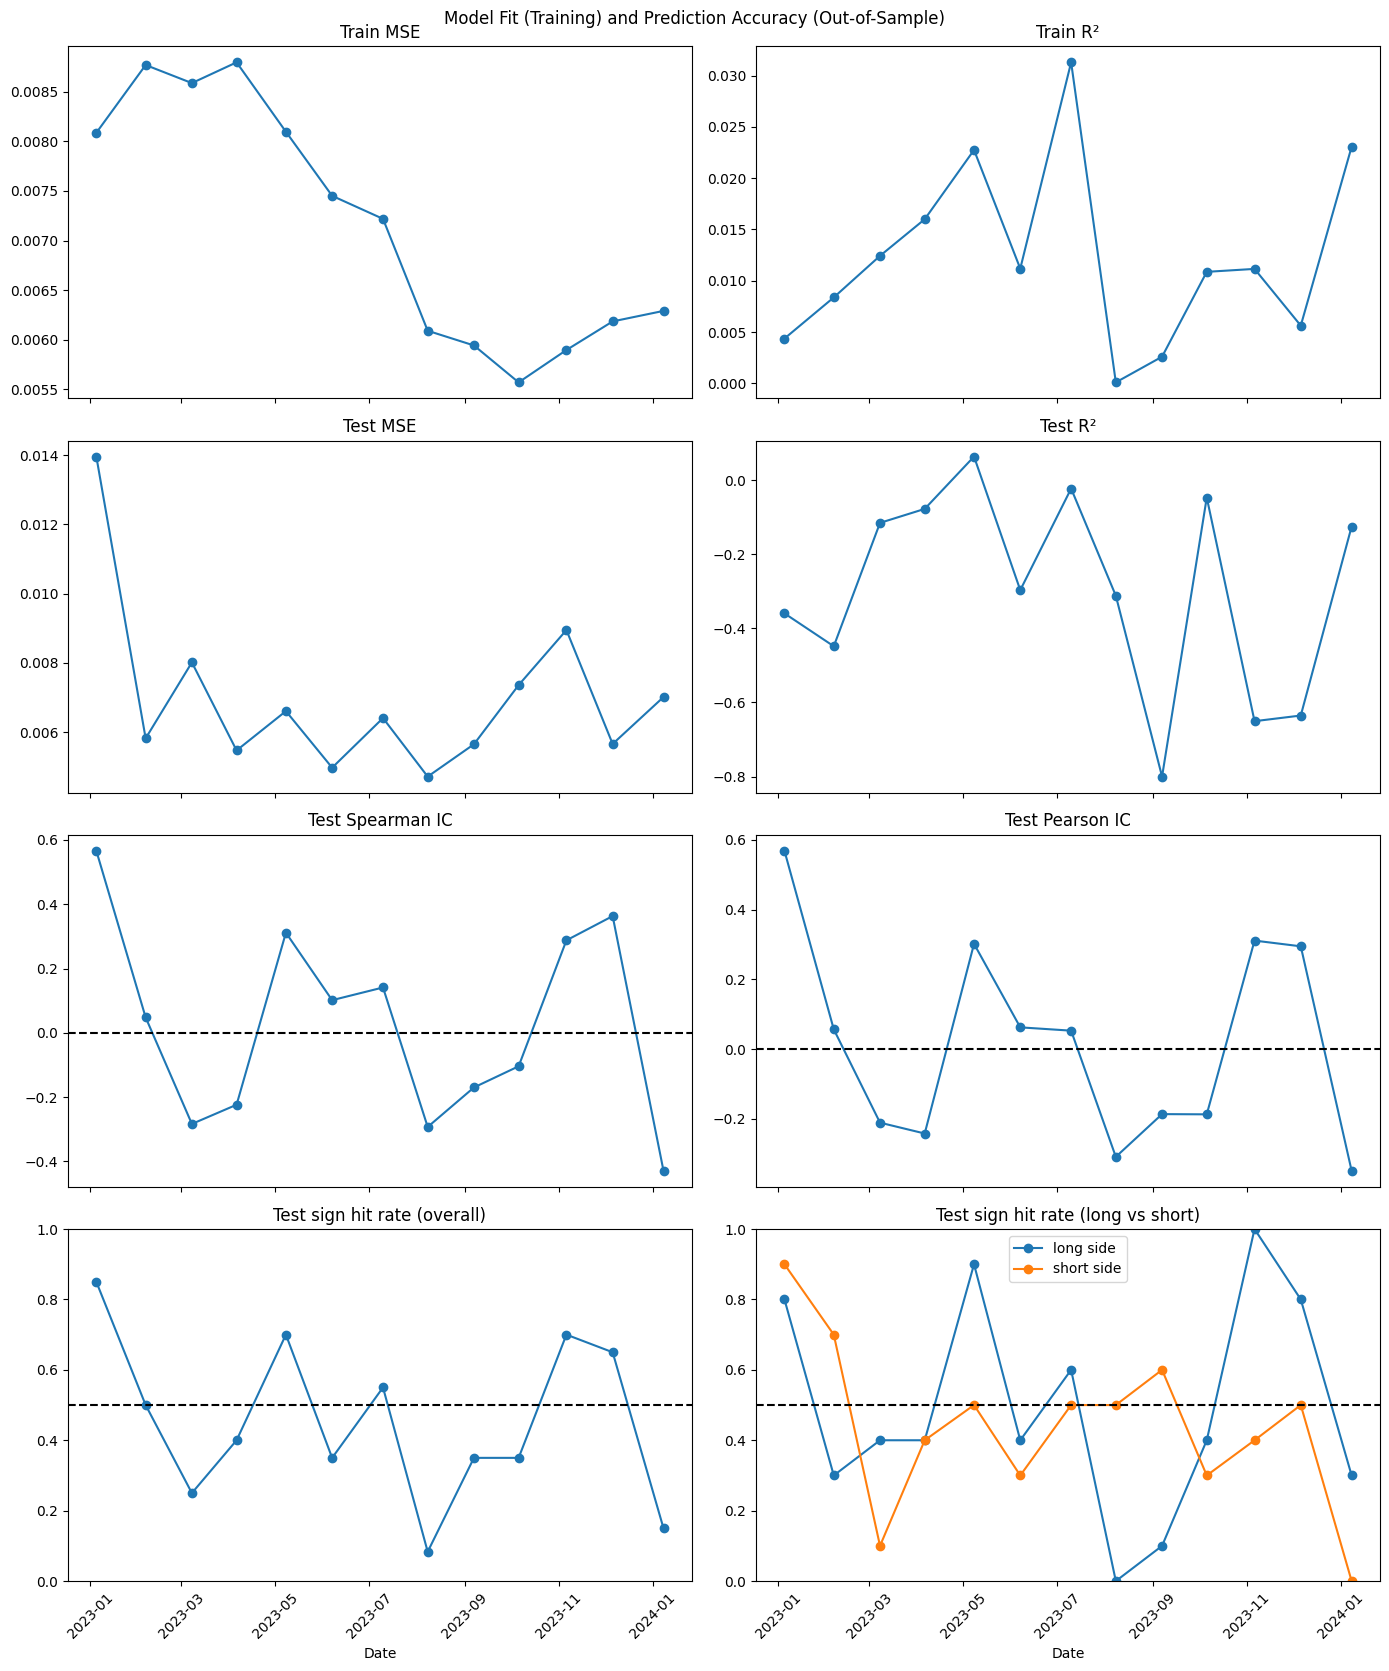

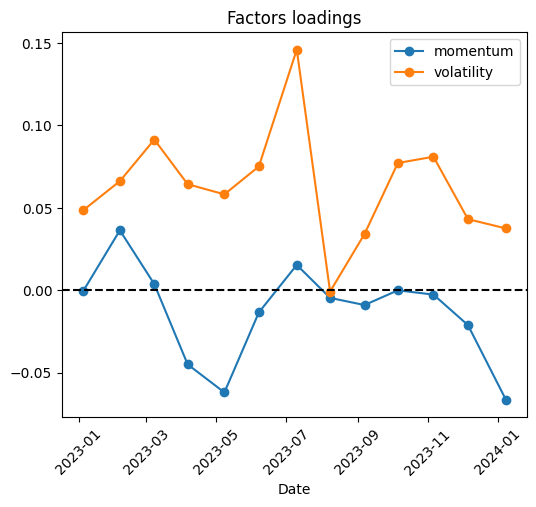

In [17]:
plot_coefs = True
show_markers = True

rpm.plot_diagnostics(
                in_sample_metrics,
                 out_sample_metrics,
                 coefs,  
                 plot_coefs = plot_coefs,
                show_markers = show_markers
                )

**Means of metrics:**

In [18]:
mean_metrics = pd.concat(
    [
        in_sample_metrics.mean().to_frame(name='in_sample'),
        out_sample_metrics.mean().to_frame(name='out_sample')
    ],
    axis=1
)

mean_metrics

,in_sample,out_sample
mse,0.007152,0.006968
r2,0.012291,-0.294614
spearman_corr,NaN,0.024425
pearson_corr,NaN,0.012394
sign_hit_rate,NaN,0.452564
sign_hit_rate_long,NaN,0.492308
sign_hit_rate_short,NaN,0.438462


**Standard deviations of metrics**:

In [19]:
std_metrics = pd.concat(
    [
        in_sample_metrics.std().to_frame(name='in_sample'),
        out_sample_metrics.std().to_frame(name='out_sample')
    ],
    axis=1
)

std_metrics

,in_sample,out_sample
mse,0.001210,0.002425
r2,0.008988,0.273502
spearman_corr,NaN,0.302395
pearson_corr,NaN,0.288186
sign_hit_rate,NaN,0.229920
sign_hit_rate_long,NaN,0.306761
sign_hit_rate_short,NaN,0.236426


**Condition numbers of the design matrix:**

In [20]:
condition_numbers

2023-01-05    6.121065
2023-02-06    5.223027
2023-03-08    5.163720
2023-04-06    4.176305
2023-05-08    4.039774
2023-06-07    4.126421
2023-07-10    3.654120
2023-08-08    3.231944
2023-09-07    3.180978
2023-10-06    3.172972
2023-11-06    3.157920
2023-12-06    3.063130
2024-01-08    2.973689
Name: condition_number, dtype: float64

## Comment on the aggregated metrics (results above, across the $N = 12$ rebalance dates)

We present the metrics in decreasing order of relevance to profitability, following the hierarchy of §8.11: directional accuracy first, then ranking, then level fit, then the loadings and the conditioning diagnostic.

### Sign hit rate (primary profitability metric)

The metric most directly tied to whether the traded positions make money is the sign hit rate on the top-$k$/bottom-$k$ names ($k = 10$): a hit is a long name that rose or a short name that fell.  The no-skill baseline is $0.5$ (see explanation in §8.11).

- **Mean overall hit rate $\approx 0.45$ ($\sigma \approx 0.23$).** The **long side** averages $\approx 0.49$ ($\sigma \approx 0.31$) and the **short side** $\approx 0.44$ ($\sigma \approx 0.24$); across these $N = 12$ rebalance dates, both are roughly indistinguishable from a coin flip.
- The per-date series swing across nearly the entire $[0,1]$ range (e.g. the long side hits $1.0$ on one date and $0.0$ on another; the short side $0.9$ and $0.0$), with no visible persistence. At this sample size we cannot isolate any evidence of directional skill.

### Spearman IC (secondary: ranking skill)

Given correct signs, profit is larger when the strongest predicted moves line up with the strongest realized moves; the Spearman IC measures this correlation.

- **Mean Spearman IC $\approx 0.024$ ($\sigma \approx 0.30$). (Pearson IC: mean $\approx 0.012$, $\sigma \approx 0.29$.)** The per-rebalance Spearman IC ranges from about $-0.43$ to $+0.57$ across the 12 dates. At this sample size we cannot isolate any evidence of ranking skill.

### Level-fit metrics (tertiary: over-fitting diagnostics)

These measure how well the predictions reproduce return *levels*; they do not map directly to profitability and are reported mainly to diagnose over-fitting.

- **Mean in-sample $R^2 \approx 0.012$ ($\sigma \approx 0.009$).** Positive but small. Consistent with the typical in-sample $R^2$ of a linear factor model explaining future returns, where the fraction of return variance explained by the predictions (see the characterization of $R^2$ in §8.11) is typically only a few percent or less (see Fama & MacBeth, 1973, "Risk, Return, and Equilibrium: Empirical Tests").
- **Mean out-of-sample $R^2 \approx -0.30$ ($\sigma \approx 0.27$).** A negative $R^2$ means the predicted cross-sectional returns are worse (higher sum of squared errors) than the baseline that predicts the cross-sectional-mean return for every ticker. The mean is negative and the out-of-sample $R^2$ is negative on most dates; this, alongside the positive in-sample $R^2$, is a signature of a model fitting in-sample noise that does not generalize.

## Factor loadings and condition number

Across the 12 fits, the volatility loading ranges roughly from $0.0$ to $0.15$ and the momentum loading from about $-0.07$ to $+0.04$ (see the loadings plot above). We do not attach a structural interpretation to these signs: the loadings are coordinates of the line of best fit for one particular data set, and what matters for the strategy is the out-of-sample ranking skill of the resulting predictions (the metrics above), not the sign of any individual coefficient.

The **condition number** $\kappa(A)$ ranges from $2.97$ to $6.12$ across all rebalance dates. It is not a measure of fit or predictive skill; it measures only the numerical stability of the loading estimates. By the perturbation bound of §8.10, a $1\%$ relative perturbation of the response $b = \mathcal{X}^\top\mathcal{R}$ moves the fitted $\hat\beta$ by at most $\approx 6\%$. So $\kappa(A) \lesssim 6$ tells us the regression is well-conditioned.

### Overall

Neither the directional diagnostic (sign hit rate) nor the ranking diagnostic (Spearman/Pearson IC) shows evidence of out-of-sample predictive skill at this sample size ($N = 12$); the model is well-conditioned (low $\kappa$) and with a low in-sample $R^2$ (poor fit). Its predictions do not generalize out-of-sample (mean out-of-sample $R^2 \approx -0.30$, negative on most dates).

### 6. Sweep the rolling-window length $W_{\text{factor}}$

We sweep $W_{\text{factor}}$ (the number of past rebalance dates pooled into each rolling fit) and report, for each candidate, the average out-of-sample sign hit rate on the traded names (top-$k$/bottom-$k$, §8.9) across all rebalance dates of the backtest.


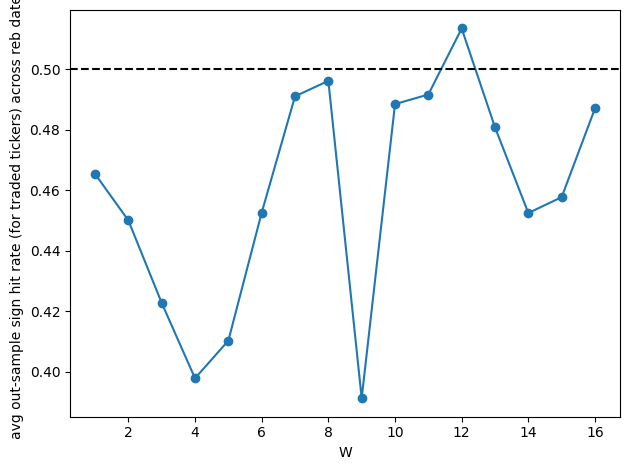

In [21]:
rolling_periods_grid = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16]

selection_k = 10

plot = True


hit_rate_by_number_of_rolling_periods_used = rpm.evaluate_rolling_periods_by_hit_rate(
                                                                            scheduled_training_rebalance_dates,
                                                                            scheduled_rebalance_dates,
                                                                            model_input,
                                                                            rolling_periods_grid,
                                                                            selection_k = selection_k,
                                                                            use_ridge = use_ridge ,
                                                                            ridge_penalty = ridge_penalty,
                                                                            plot = plot
                                                                            )

At this sample size ($N=12$ out of sample dates), every candidate $W$ produces an average hit rate hovering around the $0.50$ no-skill baseline: the curve ranges from roughly $0.39$ to $0.51$. 

An $\approx 0.51$ average hit rate is a coin flip (see explanation in  §8.11).

Given the short sample size, we do not treat the argmax ($W = 12$) as a genuinely optimal window: selecting it would be over-fitting the hyperparameter to noise, as there is no reason to expect that choice to generalize. This sweep is reported to demonstrate the methodology; with the present data and sample size it does not identify a window with directional skill. A significantly longer backtest would be required before any $W$ could be distinguished as a genuinely better choice than the others.